# HOMEWORK
* Reimplement the NeuralNetwork class by using the Perceptron class inside it (e.g. a layer is an array of perceptrons)
* Inside the class extract weights and other info from the Perceptrons to allow vector-matrix efficient multiplications
* (BONUS) make everything not using matrix multiplications, but rather for loops iterating over list of Perceptrons

## Importo le librerie

In [172]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# For reproducibility
np.random.seed(42)

## Copio la generazione del data set dall'esercizio mostrato in classe e lo plotto

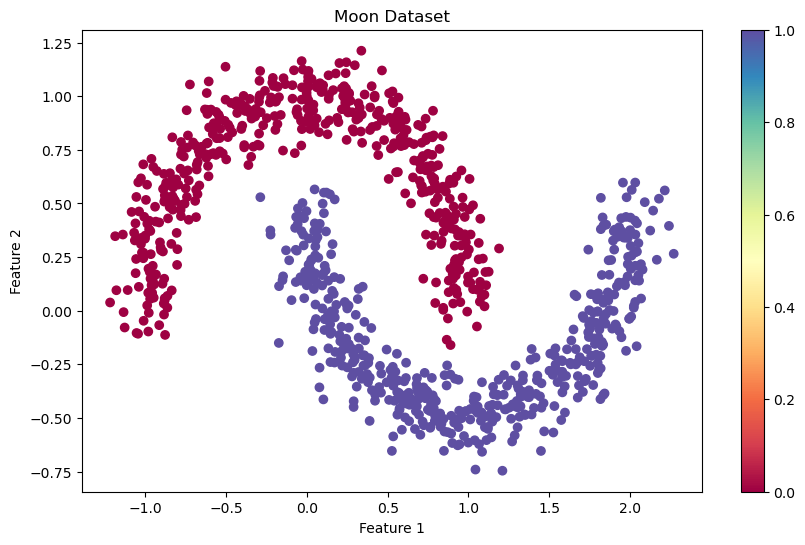

In [173]:
# Generate the dataset
X, y = make_moons(n_samples=1000, noise=0.1, random_state=42)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Visualize the data
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.Spectral)
plt.title('Moon Dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar()
plt.show()

## Lavoro sulle classi:
* La classe originale di `Perceptron` era così:
```
class Perceptron:
    def __init__(self, input_size, activation_function):
        # Initialize weights and bias with random values
        self.weights = np.random.randn(input_size)
        self.bias = np.random.randn()
        self.activation_function = activation_function
        
    def activate(self, x):
        # Compute weighted sum of inputs
        z = np.dot(x, self.weights) + self.bias
        print(z)
        print(self.weights)
        print(self.activation_function(z))
        # Apply step activation function
        #return 1 if z > 0 else 0
        return self.activation_function(z)
```

* Mentre la classe `NeuralNetwork` era:
```
class NeuralNetwork:
    def __init__(self, input_size, hidden_size, output_size):
        # Initialize weights and biases
        self.W1 = np.random.randn(input_size, hidden_size) * 0.01
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size) * 0.01
        self.b2 = np.zeros((1, output_size))
    
    def relu(self, x):
        """ReLU activation function"""
        return np.maximum(0, x)
    
    def relu_derivative(self, x):
        """Derivative of ReLU"""
        return np.where(x > 0, 1, 0)
    
    def sigmoid(self, x):
        """Sigmoid activation function"""
        return 1 / (1 + np.exp(-np.clip(x, -500, 500)))  # Clip to prevent overflow
    
    def sigmoid_derivative(self, x):
        """Derivative of sigmoid"""
        s = self.sigmoid(x)
        return s * (1 - s)
    
    def forward(self, X):
        """Forward propagation"""
        # First layer (input -> hidden)
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = self.relu(self.z1)
        
        # Second layer (hidden -> output)
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = self.sigmoid(self.z2)
        
        return self.a2
    
    def compute_loss(self, y_true, y_pred):
        """Binary cross-entropy loss"""
        m = y_true.shape[0]
        loss = -np.sum(y_true * np.log(y_pred + 1e-15) + (1 - y_true) * np.log(1 - y_pred + 1e-15)) / m
        return loss
    
    def backward(self, X, y):
        """Backward propagation to compute gradients"""
        m = X.shape[0]
        
        # Output layer gradients
        dz2 = self.a2 - y.reshape(-1, 1)
        dW2 = np.dot(self.a1.T, dz2) / m
        db2 = np.sum(dz2, axis=0, keepdims=True) / m
        
        # Hidden layer gradients
        dz1 = np.dot(dz2, self.W2.T) * self.relu_derivative(self.z1)
        dW1 = np.dot(X.T, dz1) / m
        db1 = np.sum(dz1, axis=0, keepdims=True) / m
        
        return dW1, db1, dW2, db2
    
    def update_parameters(self, dW1, db1, dW2, db2, learning_rate):
        """Update weights and biases using gradient descent"""
        self.W1 -= learning_rate * dW1
        self.b1 -= learning_rate * db1
        self.W2 -= learning_rate * dW2
        self.b2 -= learning_rate * db2
    
    def train(self, X, y, learning_rate=0.1, epochs=1000, print_every=100):
        """Train the neural network"""
        losses = []
        
        for epoch in range(epochs):
            # Forward pass
            y_pred = self.forward(X)
            
            # Compute loss
            loss = self.compute_loss(y.reshape(-1, 1), y_pred)
            losses.append(loss)
            
            # Backward pass
            dW1, db1, dW2, db2 = self.backward(X, y)
            
            # Update parameters
            self.update_parameters(dW1, db1, dW2, db2, learning_rate)
            
            # Print progress
            if epoch % print_every == 0:
                print(f"Epoch {epoch}, Loss: {loss:.4f}")
        
        return losses
    
    def predict(self, X, threshold=0.5):
        """Make binary predictions"""
        y_pred = self.forward(X)
        return (y_pred >= threshold).astype(int)
```

## To do
Dovendo reimplementare la classe `NeuralNetwork` usando la classe `Perceptron` devo creare un insieme di oggetti `Perceptron` per ogni layer della rete neurale. Ogni Layer quindi diventerà un array di percettroni, e ogni percettrone è come se fosse un neurone di quel layer.

Devo poter estrerre  i pesi dei vari percettroni e orgnizzarli in matrici, perché devo poterli usare in `forward` e `backward propagation`.

### Estendo la classe Pereptron
La classe Perceptron originale è stata estesaa per supportare meglio l'integrazione in una rete neurale completa:

* **Aggiunta di tracciamento interno**: Ho aggiunto le variabili `last_input`, `last_output` e `last_activation` per memorizzare lo stato durante il forward pass, essenziali per un backpropagation efficiente.
* **Metodi getter e setter**: Per facilitare l'accesso e la modifica dei pesi e bias, sono stati aggiunti:

    * `get_weights()` e `get_bias()` per estrarre i parametri
    * `set_weights()` e `set_bias()` per aggiornare i parametri dopo l'apprendimento


* **Migliore inizializzazione**: I pesi vengono ora scalati di un fattore 0.01 per prevenire la saturazione dei neuroni durante le fasi iniziali di addestramento. (erano così anche nella classe originale)


In [174]:
class Perceptron:
    def __init__(self, input_size, activation_function):
        # Initialize weights and bias with random values
        self.weights = np.random.randn(input_size) * 0.01
        self.bias = np.random.randn() * 0.01
        self.activation_function = activation_function
        self.last_input = None
        self.last_output = None
        self.last_activation = None
        
    def activate(self, x):
        # Save input for backpropagation
        self.last_input = x
        
        # Compute weighted sum of inputs
        z = np.dot(x, self.weights) + self.bias
        self.last_activation = z
        
        # Apply activation function
        output = self.activation_function(z)
        self.last_output = output
        
        return output
    
    def get_weights(self):
        return self.weights
    
    def get_bias(self):
        return self.bias
    
    def set_weights(self, weights):
        self.weights = weights
        
    def set_bias(self, bias):
        self.bias = bias

### Modifico la classe Neural Network
Ho reimplementato la classe NeuralNetwork per utilizzare i Perceptron come componenti.
* **Struttura a layers**: Ogni layer è ora rappresentato come un array di oggetti Perceptron
* I 2 metodi `extract_parameters()` e `update_perceptrons()` la prima estrae i pesi e bias dai Perceptron in matrici per fare i calcoli con vettori in maniera più rapida, e la seconda sincronizza le metrici di pesi aggiornate con gli oggetti Percptron.

In [175]:
class NeuralNetwork:
    def __init__(self, input_size, hidden_size, output_size):
        # Initialize layers using Perceptron instances
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        
        # Create hidden layer perceptrons with ReLU activation
        self.hidden_layer = [Perceptron(input_size, self.relu) for _ in range(hidden_size)]
        
        # Create output layer perceptrons with sigmoid activation
        self.output_layer = [Perceptron(hidden_size, self.sigmoid) for _ in range(output_size)]
        
        # Extract weights and biases for efficient computation
        self.extract_parameters()
    
    def extract_parameters(self):
        """Extract weights and biases from perceptrons for matrix operations"""
        # Extract hidden layer weights and biases
        self.W1 = np.array([p.get_weights() for p in self.hidden_layer]).T
        self.b1 = np.array([p.get_bias() for p in self.hidden_layer]).reshape(1, -1)
        
        # Extract output layer weights and biases
        self.W2 = np.array([p.get_weights() for p in self.output_layer]).T
        self.b2 = np.array([p.get_bias() for p in self.output_layer]).reshape(1, -1)
    
    def update_perceptrons(self):
        """Update perceptrons with the current weights and biases"""
        # Update hidden layer perceptrons
        for i, perceptron in enumerate(self.hidden_layer):
            perceptron.set_weights(self.W1[:, i])
            perceptron.set_bias(self.b1[0, i])
        
        # Update output layer perceptrons
        for i, perceptron in enumerate(self.output_layer):
            perceptron.set_weights(self.W2[:, i])
            perceptron.set_bias(self.b2[0, i])
    
    def relu(self, x):
        """ReLU activation function"""
        return np.maximum(0, x)
    
    def relu_derivative(self, x):
        """Derivative of ReLU"""
        return np.where(x > 0, 1, 0)
    
    def sigmoid(self, x):
        """Sigmoid activation function"""
        return 1 / (1 + np.exp(-np.clip(x, -500, 500)))  # Clip to prevent overflow
    
    def sigmoid_derivative(self, x):
        """Derivative of sigmoid"""
        s = self.sigmoid(x)
        return s * (1 - s)
    
    def forward(self, X):
        """Forward propagation using matrix multiplication"""
        # First layer (input -> hidden)
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = self.relu(self.z1)
        
        # Second layer (hidden -> output)
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = self.sigmoid(self.z2)
        
        return self.a2
    
    def compute_loss(self, y_true, y_pred):
        """Binary cross-entropy loss"""
        m = y_true.shape[0]
        loss = -np.sum(y_true * np.log(y_pred + 1e-15) + (1 - y_true) * np.log(1 - y_pred + 1e-15)) / m
        return loss
    
    def backward(self, X, y):
        """Backward propagation to compute gradients"""
        m = X.shape[0]
        
        # Output layer gradients
        dz2 = self.a2 - y.reshape(-1, 1)
        dW2 = np.dot(self.a1.T, dz2) / m
        db2 = np.sum(dz2, axis=0, keepdims=True) / m
        
        # Hidden layer gradients
        dz1 = np.dot(dz2, self.W2.T) * self.relu_derivative(self.z1)
        dW1 = np.dot(X.T, dz1) / m
        db1 = np.sum(dz1, axis=0, keepdims=True) / m
        
        return dW1, db1, dW2, db2
    
    def update_parameters(self, dW1, db1, dW2, db2, learning_rate):
        """Update weights and biases using gradient descent"""
        self.W1 -= learning_rate * dW1
        self.b1 -= learning_rate * db1
        self.W2 -= learning_rate * dW2
        self.b2 -= learning_rate * db2
        
        # Update the perceptrons with the new weights and biases
        self.update_perceptrons()
    
    def train(self, X, y, learning_rate=0.1, epochs=1000, print_every=100):
        """Train the neural network"""
        losses = []
        
        for epoch in range(epochs):
            # Forward pass
            y_pred = self.forward(X)
            
            # Compute loss
            loss = self.compute_loss(y.reshape(-1, 1), y_pred)
            losses.append(loss)
            
            # Backward pass
            dW1, db1, dW2, db2 = self.backward(X, y)
            
            # Update parameters
            self.update_parameters(dW1, db1, dW2, db2, learning_rate)
            
            # Print progress
            if epoch % print_every == 0:
                print(f"Epoch {epoch}, Loss: {loss:.4f}")
        
        return losses
    
    def predict(self, X, threshold=0.5):
        """Make binary predictions"""
        y_pred = self.forward(X)
        return (y_pred >= threshold).astype(int)

In [176]:
# Training
# set hyperparameters
hidden_size = 100
learning_rate = 0.3
epochs = 2000


# Create a neural network  (matrici)
nn_matrix = NeuralNetwork(input_size=2, hidden_size=hidden_size, output_size=1)
# Train the network (con matrici)
losses_matrix = nn_matrix.train(X, y, learning_rate=learning_rate, epochs=epochs, print_every=100)



Epoch 0, Loss: 0.6933
Epoch 100, Loss: 0.2738
Epoch 200, Loss: 0.2524
Epoch 300, Loss: 0.2515
Epoch 400, Loss: 0.2511
Epoch 500, Loss: 0.2505
Epoch 600, Loss: 0.2491
Epoch 700, Loss: 0.2461
Epoch 800, Loss: 0.2398
Epoch 900, Loss: 0.2289
Epoch 1000, Loss: 0.2124
Epoch 1100, Loss: 0.1885
Epoch 1200, Loss: 0.1564
Epoch 1300, Loss: 0.1226
Epoch 1400, Loss: 0.0937
Epoch 1500, Loss: 0.0712
Epoch 1600, Loss: 0.0512
Epoch 1700, Loss: 0.0394
Epoch 1800, Loss: 0.0321
Epoch 1900, Loss: 0.0271


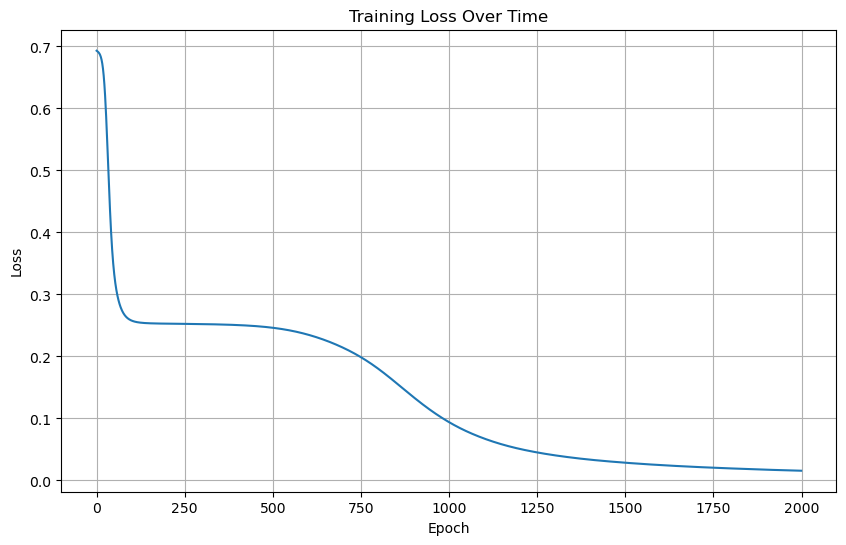

In [177]:
# Plot the loss curve
plt.figure(figsize=(10, 6))
plt.plot(losses)
plt.title('Training Loss Over Time')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

In [178]:
# Make predictions on test set
y_pred = nn_matrix.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {accuracy:.4f}")

Test accuracy: 1.0000


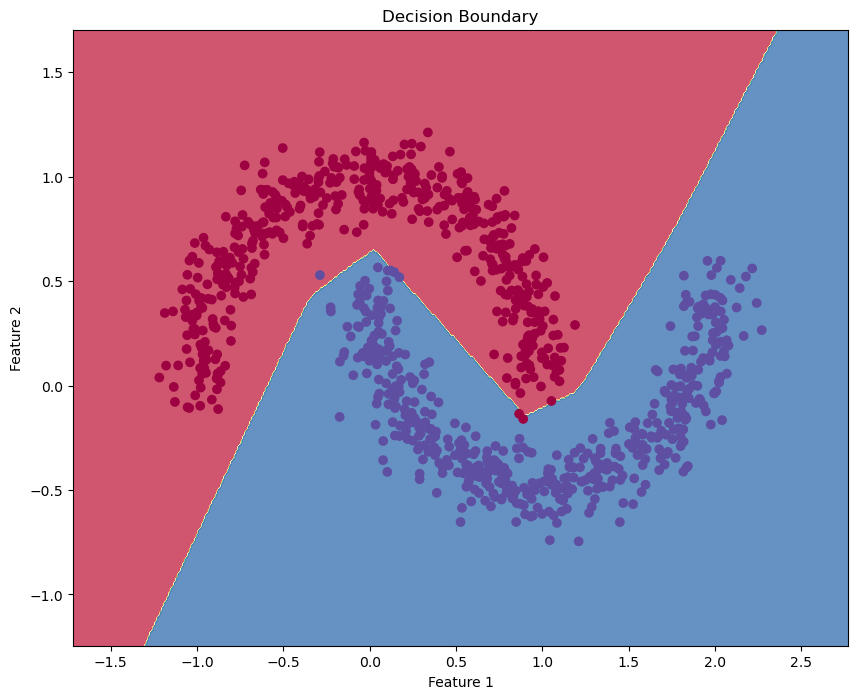

In [179]:
def plot_decision_boundary(X, y, model):
    """Plot the decision boundary of the trained model"""
    # Set min and max values with some margin
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    
    # Generate a grid of points
    h = 0.01
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    
    # Make predictions on the grid points
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Plot the contour and training examples
    plt.figure(figsize=(10, 8))
    plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.Spectral)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title('Decision Boundary')
    plt.show()

# Plot the decision boundary
plot_decision_boundary(X, y, nn_matrix)

## Bonus
Estendo la classe `NeuralNetwork` per crearne una che sovrascriva alcuni metodi per avere l'approccio iterativo e non con le matrici.
Sovrascrivo solo i metodi che devono usare l'approccio senza matrici:

* `forward()`
* `backward()`
* `compute_loss()`
* `train()`


In [180]:
class NeuralNetworkNoMatrix(NeuralNetwork):
    """Neural Network implementation without matrix operations - inherits from NeuralNetwork"""
    
    def __init__(self, input_size, hidden_size, output_size):
        # Call the parent constructor to initialize perceptrons
        super().__init__(input_size, hidden_size, output_size)
    
    def forward(self, X):
        """Override forward to use individual perceptron operations instead of matrix ops"""
        m = X.shape[0]  # Number of samples
        
        # Initialize output arrays
        hidden_outputs = np.zeros((m, self.hidden_size))
        final_outputs = np.zeros((m, self.output_size))
        
        # Process each sample
        for i in range(m):
            # Forward through hidden layer
            for j, perceptron in enumerate(self.hidden_layer):
                hidden_outputs[i, j] = perceptron.activate(X[i])
            
            # Forward through output layer
            for k, perceptron in enumerate(self.output_layer):
                final_outputs[i, k] = perceptron.activate(hidden_outputs[i])
        
        # Store activations for backpropagation
        self.a1 = hidden_outputs
        self.a2 = final_outputs
        
        return final_outputs
    
    def compute_loss(self, y_true, y_pred):
        """Binary cross-entropy loss computed manually without matrix operations"""
        m = y_true.shape[0]
        total_loss = 0
        
        for i in range(m):
            for j in range(y_pred.shape[1]):
                y_t = y_true[i, j] if y_true.ndim > 1 else y_true[i]
                y_p = y_pred[i, j]
                
                # Prevent log(0)
                if y_p < 1e-15:
                    y_p = 1e-15
                elif y_p > 1 - 1e-15:
                    y_p = 1 - 1e-15
                
                # Compute loss for this example
                sample_loss = -y_t * np.log(y_p) - (1 - y_t) * np.log(1 - y_p)
                total_loss += sample_loss
        
        return total_loss / m
    
    def backward(self, X, y):
        """Override backward to use individual perceptrons instead of matrix ops"""
        m = X.shape[0]
        
        # Initialize gradients in the expected format for compatibility with parent class
        dW1 = np.zeros_like(self.W1)
        db1 = np.zeros_like(self.b1)
        dW2 = np.zeros_like(self.W2)
        db2 = np.zeros_like(self.b2)
        
        # Process each sample
        for i in range(m):
            # 1. Output layer errors
            output_deltas = []
            for j in range(self.output_size):
                y_true = y[i] if y.ndim == 1 else y[i, j]
                # Error at output (predicted - true)
                error = self.a2[i, j] - y_true
                output_deltas.append(error)
                
                # Update output weights gradients
                for k in range(self.hidden_size):
                    dW2[k, j] += error * self.a1[i, k]
                
                # Update output bias gradients
                db2[0, j] += error
            
            # 2. Hidden layer errors
            for j in range(self.hidden_size):
                # Sum of weighted deltas from output layer
                error_sum = 0
                for k in range(self.output_size):
                    error_sum += output_deltas[k] * self.W2[j, k]
                
                # Get activation value
                activation = self.hidden_layer[j].last_activation
                
                # Apply derivative of activation function
                delta = error_sum * (1 if activation > 0 else 0)  # ReLU derivative
                
                # Update hidden weights gradients
                for k in range(self.input_size):
                    dW1[k, j] += delta * X[i, k]
                
                # Update hidden bias gradients
                db1[0, j] += delta
        
        # Average the gradients
        dW1 /= m
        db1 /= m
        dW2 /= m
        db2 /= m
        
        return dW1, db1, dW2, db2
    
    def train(self, X, y, learning_rate=0.1, epochs=1000, print_every=100):
        """Train using individual perceptron operations"""
        losses = []
        y = np.array(y).reshape(-1, 1) if np.array(y).ndim == 1 else np.array(y)
        
        for epoch in range(epochs):
            # Forward pass
            y_pred = self.forward(X)
            
            # Compute loss
            loss = self.compute_loss(y, y_pred)
            losses.append(loss)
            
            # Backward pass
            dW1, db1, dW2, db2 = self.backward(X, y)
            
            # Update parameters - reuse parent method
            self.update_parameters(dW1, db1, dW2, db2, learning_rate)
            
            # Print progress
            if epoch % print_every == 0:
                print(f"Epoch {epoch}, Loss: {loss:.4f}")
        
        return losses

In [181]:
# Create a neural network  ( NO matrici)
nn_non_matrix = NeuralNetworkNoMatrix(input_size=2, hidden_size=hidden_size, output_size=1)
# Train the network (NO matrici)
losses_non_matrix = nn_non_matrix.train(X, y, learning_rate=learning_rate, epochs=epochs, print_every=100)

Epoch 0, Loss: 0.6932
Epoch 100, Loss: 0.3649
Epoch 200, Loss: 0.2988
Epoch 300, Loss: 0.2909
Epoch 400, Loss: 0.2901
Epoch 500, Loss: 0.2902
Epoch 600, Loss: 0.2900
Epoch 700, Loss: 0.2894
Epoch 800, Loss: 0.2887
Epoch 900, Loss: 0.2880
Epoch 1000, Loss: 0.2875
Epoch 1100, Loss: 0.2870
Epoch 1200, Loss: 0.2867
Epoch 1300, Loss: 0.2863
Epoch 1400, Loss: 0.2860
Epoch 1500, Loss: 0.2857
Epoch 1600, Loss: 0.2855
Epoch 1700, Loss: 0.2853
Epoch 1800, Loss: 0.2850
Epoch 1900, Loss: 0.2848


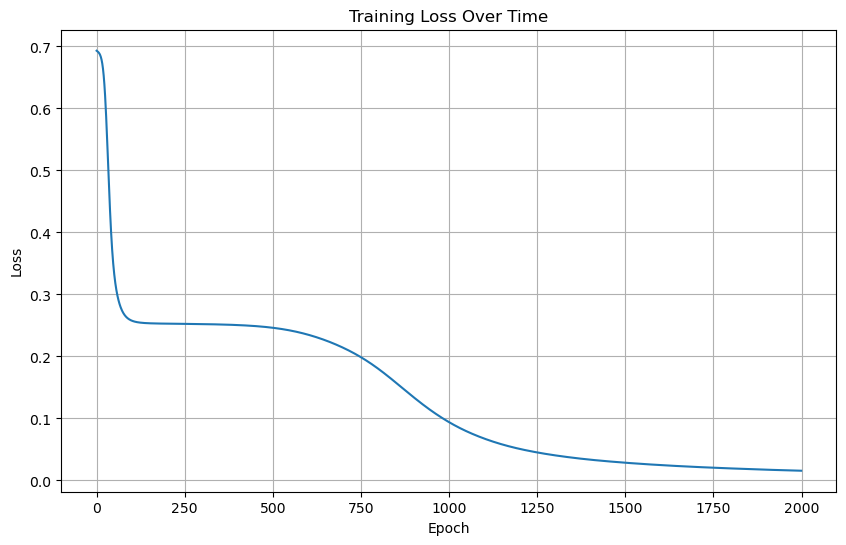

In [182]:
# Plot the loss curve
plt.figure(figsize=(10, 6))
plt.plot(losses)
plt.title('Training Loss Over Time')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

In [183]:
# Make predictions on test set
y_pred_non_matrix = nn_non_matrix.predict(X_test)

# Calculate accuracy
accuracy_non_matrix = accuracy_score(y_test, y_pred_non_matrix)
print(f"Test accuracy: {accuracy_non_matrix:.4f}")

Test accuracy: 0.8850


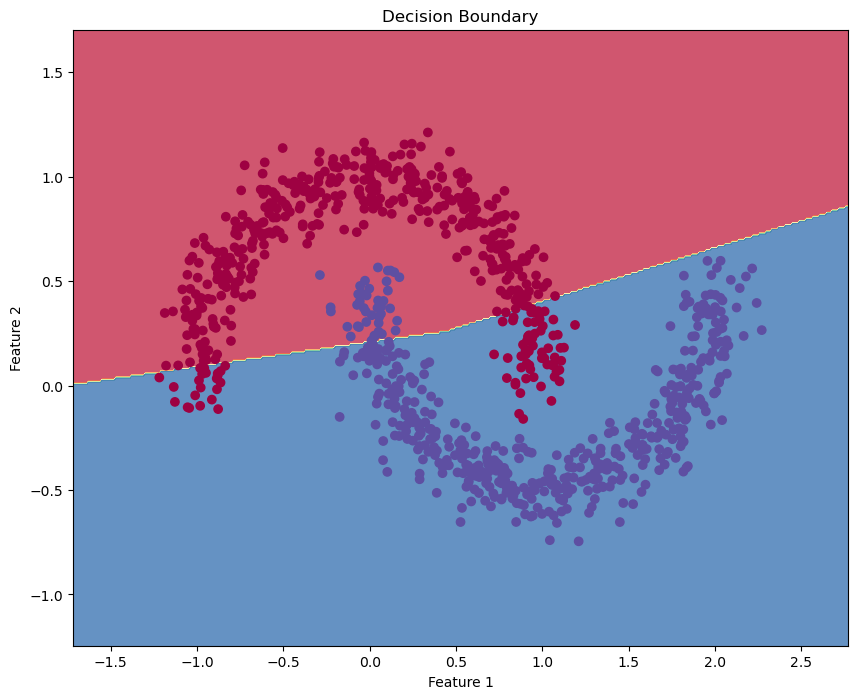

In [184]:
# Plot the decision boundary
plot_decision_boundary(X, y, nn_non_matrix)